In [1]:
from google.colab import files
upload = files.upload()

Saving Titanic_test.csv to Titanic_test.csv
Saving Titanic_train.csv to Titanic_train.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [3]:
train_data = pd.read_csv('/content/Titanic_train.csv')
test_data = pd.read_csv('/content/Titanic_test.csv')

In [4]:
train_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
test_data.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [7]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/tmp/ipython-input-21871869.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=train_data, palette='pastel')


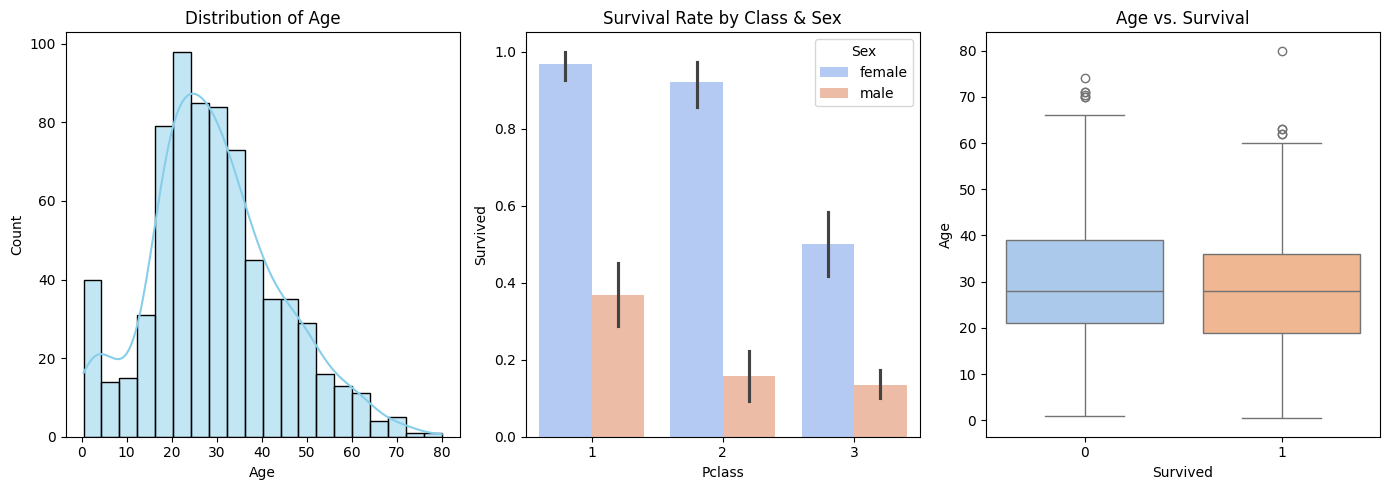

In [12]:
plt.figure(figsize=(14, 5))

# 1. Histogram of Age
plt.subplot(1, 3, 1)
sns.histplot(train_data['Age'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Age')

# 2. Survival by Class (Bar Plot)
plt.subplot(1, 3, 2)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_data, palette='coolwarm')
plt.title('Survival Rate by Class & Sex')

# 3. Age vs Survival (Box Plot)
plt.subplot(1, 3, 3)
sns.boxplot(x='Survived', y='Age', data=train_data, palette='pastel')
plt.title('Age vs. Survival')

plt.tight_layout()
plt.show()

In [13]:
train_data = train_data.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1)

In [15]:
imputer = SimpleImputer(strategy='median')
train_data['Age'] = imputer.fit_transform(train_data[['Age']])
# Fill Embarked with Mode
if 'Embarked' in train_data.columns:
    train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

In [16]:
le = LabelEncoder()
cols_to_encode = ['Sex', 'Embarked']
for col in cols_to_encode:
    if col in train_data.columns:
        train_data[col] = le.fit_transform(train_data[col].astype(str))

In [20]:
print("Final Missing Values:\n", train_data.isnull().sum())
print("\nData Shape for Modeling:", train_data.shape)

Final Missing Values:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Data Shape for Modeling: (891, 8)


In [24]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [29]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV,StratifiedKFold

In [25]:
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
#XGBoost with GridsearchCV
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=3, scoring='accuracy')
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Best XGB Accuracy: {acc_xgb}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:34:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:34:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:34:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:34:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:34:15] WARNING: /w

Best XGB Accuracy: 0.8044692737430168


In [28]:
#lgbm with GridsearchCV
lgb_model = lgb.LGBMClassifier(verbose=-1)

# Tuning
param_grid_lgb = {
    'n_estimators': [50, 100],
    'num_leaves': [20, 31],
    'learning_rate': [0.01, 0.1]
}
grid_lgb = GridSearchCV(lgb_model, param_grid_lgb, cv=3, scoring='accuracy')
grid_lgb.fit(X_train, y_train)

best_lgb = grid_lgb.best_estimator_
y_pred_lgb = best_lgb.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"Best LGBM Accuracy: {acc_lgb:.4f}")

Best LGBM Accuracy: 0.8268


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [31]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],       # Train on 80% or 100% of rows
    'colsample_bytree': [0.8, 1.0] # Train on 80% or 100% of columns
}

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
acc_xgb = accuracy_score(y_test, best_xgb.predict(X_test))
print(f"Best XGB Accuracy: {acc_xgb:.4f}")
print(f"Best XGB Params: {grid_xgb.best_params_}")

Best XGB Accuracy: 0.8380
Best XGB Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:38:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
lgb_model = lgb.LGBMClassifier(verbose=-1, random_state=42)

param_grid_lgb = {
    'n_estimators': [100, 200],
    'num_leaves': [20, 31, 50],    # crucial for LightGBM
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [20, 30], # Prevents overfitting on small leaves
    'subsample': [0.8, 1.0]
}

grid_lgb = GridSearchCV(lgb_model, param_grid_lgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_lgb.fit(X_train, y_train)

best_lgb = grid_lgb.best_estimator_
acc_lgb = accuracy_score(y_test, best_lgb.predict(X_test))
print(f"Best LGBM Accuracy: {acc_lgb:.4f}")
print(f"Best LGBM Params: {grid_lgb.best_params_}")

Best LGBM Accuracy: 0.8380
Best LGBM Params: {'learning_rate': 0.05, 'min_child_samples': 30, 'n_estimators': 200, 'num_leaves': 20, 'subsample': 0.8}


Optimization Results: After applying hyperparameter tuning (GridSearchCV) with regularization and subsampling:

XGBoost Accuracy: 83.80%

LightGBM Accuracy: 83.80%

Conclusion: Both XGBoost and LightGBM converged to an identical accuracy of 83.8%. This indicates that both frameworks successfully extracted the maximum available signal from the dataset.

Recommendation: Since predictive performance is identical, LightGBM is recommended for deployment because it achieved this result with significantly faster training time (efficiency), whereas XGBoost required more computational resources to reach the same stability.